In [2]:
import json
from pathlib import Path
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def load_experiment_results(base_dir="../src/logs"):
    data_list = []
    base_path = Path(base_dir)
    pattern = "*/*/*/version_0/eval/version_0/test_results.json"

    for json_path in base_path.glob(pattern):
        relative_parts = json_path.relative_to(base_path).parts

        loss_combination = relative_parts[0]
        dataset = relative_parts[1]
        weight_map = relative_parts[2]

        # Read the JSON file
        try:
            with open(json_path, "r") as f:
                metrics = json.load(f)

            row = {
                "loss_combination": loss_combination,
                "dataset": dataset,
                "weight_map": weight_map,
                **metrics,  # Flattens the JSON content into the dict
            }
            data_list.append(row)

        except (json.JSONDecodeError, IOError) as e:
            print(f"Error reading {json_path}: {e}")

    df = pd.DataFrame(data_list)
    #df = pd.merge(pd.read_parquet("experiment_results.parquet"), pd.DataFrame(data_list))
    return df


df = load_experiment_results()

df.set_index(["loss_combination", "dataset", "weight_map"], inplace=True)

In [16]:
# df.to_parquet("experiment_results.parquet")
#df_existing = pd.read_parquet("experiment_results.parquet")
total_df = pd.concat([df, df_existing])


In [3]:
df = pd.read_parquet('experiment_results.parquet')
df

test/global/dice  \
loss_combination dataset          weight_map                      
220110           sbm_mets         none                 0.535532   
                 wmh_wmh          none                 0.483420   
110000           sbm_mets         v_iw                 0.043352   
                                  v_mountains          0.454525   
                                  v_islands            0.461075   
...                                                         ...   
220110           plateletclean_ag none                 0.812332   
                 epflclean_mit    none                 0.938979   
000110           plateletclean_cv none                 0.813221   
                 plateletclean_ag none                 0.820226   
                 epflclean_mit    none                 0.944656   

                                               test/global/precision  \
loss_combination dataset          weight_map                           
220110           sbm_mets         none                      0.737262   
                 wmh_wmh          none                      0.870476   
110000           sbm_mets         v_iw                      0.024452   
                                  v_mountains               0.563039   
                                  v_islands                 0.442343   
...                                                              ...   
220110           plateletclean_ag none                      0.825375   
                 epflclean_mit    none                      0.939933   
000110           plateletclean_cv none                      0.840656   
                 plateletclean_ag none                      0.807065   
                 epflclean_mit    none                      0.936796   

                                               test/global/recall  \
loss_combination dataset          weight_map                        
220110           sbm_mets         none                   0.447818   
                 wmh_wmh          none                   0.320898   
110000           sbm_mets         v_iw                   0.960610   
                                  v_mountains            0.486815   
                                  v_islands              0.584571   
...                                                           ...   
220110           plateletclean_ag none                   0.822888   
                 epflclean_mit    none                   0.943157   
000110           plateletclean_cv none                   0.786063   
                 plateletclean_ag none                   0.862997   
                 epflclean_mit    none                   0.956463   

                                               test/global/F2  test/cc/dice  \
loss_combination dataset          weight_map                                  
220110           sbm_mets         none               0.485976      0.428713   
                 wmh_wmh          none               0.367273      0.250119   
110000           sbm_mets         v_iw               0.110963      0.044151   
                                  v_mountains        0.500363      0.382303   
                                  v_islands          0.549251      0.373121   
...                                                       ...           ...   
220110           plateletclean_ag none               0.823384      0.659905   
                 epflclean_mit    none               0.942510      0.907155   
000110           plateletclean_cv none               0.796407      0.747267   
                 plateletclean_ag none               0.851199      0.695247   
                 epflclean_mit    none               0.952464      0.923076   

                                               test/instance/dice  \
loss_combination dataset          weight_map                        
220110           sbm_mets         none                   0.549041   
                 wmh_wmh          none                   0.495494   
110000           sbm_mets         v_

In [4]:
COLORS = {
    'good': "#6aa84f",
    'bad': "#cc4125",
    'neutral': '#616161',
}

def readable_losses(number_string):
    glob = number_string[:3]
    local = number_string[-3:]
    readablegl = ""
    readablelo = ""
    if glob == '000':
        readablegl += 'none'
    if glob == '220':
        readablegl += '2*DiceCE'
    if glob[0] == '1':
        readablegl += 'Dice'
    if glob[1] == '1':
        readablegl += 'CE'
    if glob[2] == '1':
        readablegl += 'Tversky'
    if local == '000':
        readablelo += 'none'
    if local == '220':
        readablelo += '2*DiceCE'
    if local[0] == '1':
        readablelo += 'Dice'
    if local[1] == '1':
        readablelo += 'CE'
    if local[2] == '1':
        readablelo += 'Tversky'
    return (readablegl, readablelo)


metricreadable = {
    "test/global/dice": "DSC",
    "test/global/F2": "F2",
    "test/instance/f1": "RQ",
    "test/instance/dice": "SQDSC",
    "test/instance/assd": "SQASSD",
    "test/instance/recall":  "recall_inst",
    "test/instance/recall_Q1": "recall_inst_Q1",
    "test/instance/recall_Q2": "recall_inst_Q2",
    "test/instance/recall_Q3": "recall_inst_Q3",
    "test/instance/recall_Q4": "recall_inst_Q4",
    "test/instance/SQDSC_Q1": "SQDSC_Q1",
    "test/instance/SQDSC_Q2": "SQDSC_Q2",
    "test/instance/SQDSC_Q3": "SQDSC_Q3",
    "test/instance/SQDSC_Q4": "SQDSC_Q4",
    "test/cc/dice": "CCDice",
    "test/global/precision": "precision",
    "test/global/recall": "recall",
    "test/instance/precision": "precision_inst",
}

In [21]:
def plot_baseline_comparison(
    df, metric, baseline_tuple, comparison_tuples, experiment, save_path
):
    assert experiment in ['loss_combos', 'weight_maps']
    if baseline_tuple not in df.index:
        raise KeyError(
            f"Baseline tuple {baseline_tuple} was not found in the DataFrame index."
        )
    baseline_val = df.loc[baseline_tuple, metric]

    comp_vals = []
    labels = []

    for key in comparison_tuples:
        if key in df.index:
            comp_vals.append(df.loc[key, metric])
            if experiment == 'loss_combos':
                labels.append(f"{readable_losses(key[0])[0]}\n{readable_losses(key[0])[1]}")
            else: 
                labels.append(f"{key[2]}")

    comp_vals = np.array(comp_vals)
    x_positions = np.arange(len(labels))

    fig, ax = plt.subplots(figsize=(8, 5.5))

    ax.axhline(
        y=baseline_val,
        color="#7f8c8d",
        linestyle="--",
        linewidth=1.8,
        label=f"Baseline (DiceCE, none): {baseline_val:.3f}" if experiment == 'loss_combos' else "Baseline ($W_{none}$):" + f"{baseline_val:.3f}",
        zorder=1,
    )

    for x, val, label in zip(x_positions, comp_vals, labels):
        if np.isnan(val):
            continue

        diff = val - baseline_val
        if metricreadable[metric] in ['SQASSD', 'CEDI']:
            color = COLORS['neutral'] if abs(diff) < 0.001 else (COLORS['good'] if diff <= 0 else COLORS['bad'])
        else:
            color = COLORS['neutral'] if abs(diff) < 0.001 else (COLORS['good'] if diff >= 0 else COLORS['bad'])

        ax.vlines(
            x,
            ymin=baseline_val,
            ymax=val,
            colors=color,
            linewidth=2.5,
            alpha=0.8,
            zorder=2,
        )

        ax.scatter(x, val, color=color, s=140, zorder=3)

        va = "bottom" if diff >= 0 else "top"
        offset = 0.005 if diff >= 0 else -0.005
        sign = "+" if diff >= 0 else ""

        ax.text(
            x,
            val + offset,
            f"{val:.3f}\n({sign}{diff:.3f})",
            ha="center",
            va=va,
            fontsize=9.5,
            fontweight="bold",
            color=color,
        )

    ax.set_xticks(x_positions)
    ax.set_xmargin(0.1)
    ax.set_xticklabels(labels, rotation=0, fontsize=10, fontweight="medium")
    ax.set_ylabel(metricreadable[metric], fontsize=12, fontweight="bold", labelpad=10)

    valid_vals = [v for v in comp_vals if not np.isnan(v)] + [baseline_val]
    ymin, ymax = min(valid_vals), max(valid_vals)
    ax.set_ylim(ymin - 0.04, ymax + 0.04)

    ax.grid(axis="y", linestyle=":", alpha=0.5)
    ax.legend(loc="upper left", frameon=True, facecolor="#f8f9fa", edgecolor="#e2e8f0")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()


def plot_quartile_baseline_comparison(
    df, metric_list, baseline_tuple, comparison_tuples, experiment, save_path
):
    assert experiment in ['loss_combos', 'weight_maps']
    for metrics in metric_list:
        quartiles = metrics
        quartile_labels = ["Q1", "Q2", "Q3", "Q4"]

        colors = ["#1abc9c", "#3498db", "#9b59b6", "#e67e22"]

        if baseline_tuple not in df.index:
            raise KeyError(
                f"Baseline tuple {baseline_tuple} was not found in the DataFrame index.")

        baseline_vals = {q: df.loc[baseline_tuple, q] for q in quartiles}

        labels = []
        comp_data = {q: [] for q in quartiles}

        for key in comparison_tuples:
            if key in df.index:
                if experiment == 'loss_combos':
                    labels.append(
                        f"{readable_losses(key[0])[0]}\n{readable_losses(key[0])[1]}")
                else:
                    labels.append(f"{key[2]}")
                for q in quartiles:
                    comp_data[q].append(df.loc[key, q])

        num_groups = len(labels)
        x_base = np.arange(num_groups)

        total_group_width = 0.6
        step = total_group_width / len(quartiles)
        offsets = np.linspace(-total_group_width/2 + step/2,
                              total_group_width/2 - step/2, len(quartiles))

        fig, ax = plt.subplots(figsize=(16, 5.25))

        for idx, q in enumerate(quartiles):
            ax.axhline(
                y=baseline_vals[q],
                color=colors[idx],
                linestyle="--",
                linewidth=1.2,
                alpha=0.6,
                label=f"{quartile_labels[idx]} Base: {baseline_vals[q]:.2f}",
            )

        for idx, q in enumerate(quartiles):
            b_val = baseline_vals[q]

            for g_idx in range(num_groups):
                val = comp_data[q][g_idx]
                if np.isnan(val):
                    continue

                x_pos = x_base[g_idx] + offsets[idx]
                val = round(val, 3)
                b_val = round(b_val, 3)
                diff = val - b_val
                q_color = COLORS['neutral'] if abs(diff) < 0.005 else (
                    COLORS['good'] if diff >= 0 else COLORS['bad'])

                # Draw stem
                ax.vlines(
                    x_pos,
                    ymin=b_val,
                    ymax=val,
                    colors=q_color,
                    linewidth=2.0,
                    alpha=0.8,
                    zorder=2,
                )

                ax.scatter(x_pos, val, color=q_color, s=70,
                           zorder=3, edgecolors='none')

                va = "bottom" if diff >= 0 else "top"
                offset = 0.0075 if diff >= 0 else -0.0075
                sign = "+" if diff >= 0 else ""

                ax.text(
                    x_pos,
                    val + offset,
                    f"{sign}{diff:.2f}",
                    ha="center",
                    va=va,
                    fontsize=7.5,
                    fontweight="semibold",
                    color=q_color,
                )

        # 6. Formatting & Styling
        ax.set_xticks(x_base)
        ax.set_xticklabels(labels, rotation=0, fontsize=10,
                           fontweight="medium")
        ax.set_ylabel(
            "SQDSC" if 'SQDSC' in metrics[0] else "Instance Recall", fontsize=12, fontweight="bold", labelpad=10)

        # Push margins slightly so outer lollipops aren't cut off
        ax.set_xmargin(0.1)

        # Dynamically find min/max values to safely scale y limits
        all_vals = [v for q in quartiles for v in comp_data[q]
                    if not np.isnan(v)] + list(baseline_vals.values())
        ymin, ymax = min(all_vals), max(all_vals)
        ax.set_ylim(max(0, ymin - 0.06), max(0, ymax + 0.06))

        ax.grid(axis="y", linestyle=":", alpha=0.5)

        # Place Legend cleanly outside or top-left
        ax.legend(loc="upper left", frameon=True,
                  facecolor="#f8f9fa", edgecolor="#e2e8f0", fontsize=9)
        plt.tight_layout()
        plt.savefig(
            save_path + ("quartile_SQDSC_comparison.png" if 'SQDSC' in metrics[0] else "quartile_recall_comparison.png"), dpi=300)
        plt.close()
    
def generate_typst_comparison_table(
    df, metrics_list, metric_readable, baseline_tuple, comparison_tuples, experiment, task
):
    assert experiment in ['loss_combos', 'weight_maps']
    headers = [f"[{metric_readable[m]}]" for m in metrics_list]  # Fallback row titles

    num_cols = 1 + 1 + len(comparison_tuples)  # Metric Name + Baseline + Comparisons
    align_str = f"(left, {'center, ' * (num_cols - 1)})".strip(", ")

    typst_lines = [
        '#import "../../../utils.typ": *',
        f'#let {task}results-table_{experiment}() = table(',
        f"  columns: (auto, {'1fr, ' * (num_cols - 1)}).slice(0, {num_cols}),",
        f"  align: {align_str},",
        "  stroke: (",
        "    x: none,",
        "    y: 0.4pt + luma(220),",
        "  ),",
        "  inset: 8pt,",
        "",
        "  table.header(",
        "    [],",
    ]

    # Add baseline header (extracting the weight map descriptor name)
    typst_lines.append(f"    [{readable_losses(baseline_tuple[0])}],".replace(')', '').replace('(', '').replace('\'', '') if experiment=='loss_combos' else f"      [{baseline_tuple[2]}],")

    # Add comparison headers
    for key in comparison_tuples:
        typst_lines.append(f"    [{readable_losses(key[0])}],".replace(')', '').replace('(', '').replace('\'', '') if experiment=='loss_combos' else f"     [{key[2]}],")
    typst_lines.append("  ),")

    # 2. Process each metric row
    for metric in metrics_list:
        readable_name = metric_readable.get(metric, metric)

        # Handle math formatting variations for specific metrics if needed
        if readable_name == "F2":
            readable_name = "$F_2$"
        elif readable_name == "recall_inst":
            readable_name = '$"recall"_"inst"$'
        elif readable_name == "precision_inst":
            readable_name = '$"precision"_"inst"$'
        elif readable_name == "recall_inst_Q1":
            readable_name = '$"recall"_"inst"_"Q1"$'
        elif readable_name == "recall_inst_Q2":
            readable_name = '$"recall"_"inst"_"Q2"$'
        elif readable_name == "recall_inst_Q3":
            readable_name = '$"recall"_"inst"_"Q3"$'
        elif readable_name == "recall_inst_Q4":
            readable_name = '$"recall"_"inst"_"Q4"$'


        typst_lines.append(f"\n  // {metric}")
        typst_lines.append(f"  [{readable_name}],")

        # Safely get baseline
        if baseline_tuple not in df.index:
            raise KeyError(f"Baseline {baseline_tuple} not found in DataFrame.")
        baseline_val = df.loc[baseline_tuple, metric]

        # Gather comparison values
        comp_vals = []
        for key in comparison_tuples:
            if key in df.index:
                comp_vals.append(df.loc[key, metric])
            else:
                comp_vals.append(np.nan)

        all_vals = [baseline_val] + comp_vals

        # Determine the "best" score index for bolding
        # Lower is better for SQASSD and CEDI, higher is better for others
        valid_vals = [v for v in all_vals if not np.isnan(v)]
        if not valid_vals:
            continue

        if metric_readable.get(metric, metric) in ["SQASSD", "CEDI"]:
            best_val = min(valid_vals)
        else:
            best_val = max(valid_vals)

        # Render baseline cell
        is_baseline_best = np.isclose(baseline_val, best_val, atol=1e-5)
        b_cell = f"{baseline_val:.3f}"
        if is_baseline_best:
            b_cell = f"#text(size: 10.5pt)[*{b_cell}*]"
        typst_lines.append(f"  [{b_cell}],")

        # Render comparison cells
        for val in comp_vals:
            if np.isnan(val):
                typst_lines.append("  [-],")
                continue

            diff = val - baseline_val
            is_best = np.isclose(val, best_val, atol=1e-5)

            # Format the delta string
            sign = "+" if diff >= 0 else ""
            delta_cell = f"#deltainv({sign}{diff:.3f})" if metric_readable.get(metric, metric) in ["SQASSD", "CEDI"] else f"#delta({sign}{diff:.3f})" 

            # Apply bolding wrapper if this cell is the winner
            if is_best:
                delta_cell = f"#text(size: 10.5pt)[*{delta_cell}*]"

            typst_lines.append(f"  [{delta_cell}],")

    typst_lines.append(")")
    with open(f'../docs/thesis/figures/results/{task}/table_{experiment}_temp.typ', 'w') as f:
        f.write("\n".join(typst_lines))
    return "\n".join(typst_lines)

In [22]:

SUPERSETS = ['epflclean', 'sbm', 'wmh', 'plateletclean', 'plateletclean']
TASKS = ["mit", 'mets', 'wmh', 'cv', 'ag']
EXPERIMENT = 'loss_combos'
EXPERIMENT = 'weight_maps'

for SUPERSET, TASK in zip(SUPERSETS, TASKS):
    os.makedirs(f'../docs/thesis/figures/results/{TASK}/lollipop/{EXPERIMENT}/', exist_ok=True)

    baseline_config = ("110000", f"{SUPERSET}_{TASK}", "none")
    comparison_configs = [
        ("000110", f"{SUPERSET}_{TASK}", "none"),
        ("110110", f"{SUPERSET}_{TASK}", "none"),
        ("220110", f"{SUPERSET}_{TASK}", "none"),
        ("110220", f"{SUPERSET}_{TASK}", "none"),
        ("110101", f"{SUPERSET}_{TASK}", "none"),
        ("011101", f"{SUPERSET}_{TASK}", "none"),
    ] if EXPERIMENT == 'loss_combos' else [
        ("110000", f"{SUPERSET}_{TASK}", "v_iw"),
        ("110000", f"{SUPERSET}_{TASK}", "v_region"),
        ("110000", f"{SUPERSET}_{TASK}", "v_adaptive"),
        ("110000", f"{SUPERSET}_{TASK}", "v_mountains"),
        ("110000", f"{SUPERSET}_{TASK}", "v_islands"),
    ]
    # for metric in metricreadable.keys():
    #     plot_baseline_comparison(
    #         df=df,
    #         metric=metric,
    #         baseline_tuple=baseline_config,
    #         comparison_tuples=comparison_configs,
    #         experiment= EXPERIMENT,
    #         save_path=f'../docs/thesis/figures/results/{TASK}/lollipop/{EXPERIMENT}/{metricreadable[metric]}',
    #     )
    plot_quartile_baseline_comparison(
        df=df,
        metric_list=[['test/instance/SQDSC_Q1', 'test/instance/SQDSC_Q2', 'test/instance/SQDSC_Q3', 'test/instance/SQDSC_Q4'],
                     ['test/instance/recall_Q1', 'test/instance/recall_Q2', 'test/instance/recall_Q3', 'test/instance/recall_Q4']],
        baseline_tuple=baseline_config,
        comparison_tuples=comparison_configs,
        experiment=EXPERIMENT,
        save_path=f'../docs/thesis/figures/results/{TASK}/lollipop/{EXPERIMENT}/',
    )
    # generate_typst_comparison_table(
    #     df=df,
    #     metrics_list=metricreadable.keys(),
    #     metric_readable=metricreadable,
    #     baseline_tuple=baseline_config,
    #     comparison_tuples=comparison_configs,
    #     experiment='loss_combos',
    #     task=TASK
    # )

In [12]:
df

test/global/dice  \
loss_combination dataset          weight_map                      
220110           sbm_mets         none                 0.535532   
                 wmh_wmh          none                 0.483420   
110000           sbm_mets         v_iw                 0.043352   
                                  v_mountains          0.454525   
                                  v_islands            0.461075   
...                                                         ...   
220110           plateletclean_ag none                 0.812332   
                 epflclean_mit    none                 0.938979   
000110           plateletclean_cv none                 0.813221   
                 plateletclean_ag none                 0.820226   
                 epflclean_mit    none                 0.944656   

                                               test/global/precision  \
loss_combination dataset          weight_map                           
220110           sbm_mets         none                      0.737262   
                 wmh_wmh          none                      0.870476   
110000           sbm_mets         v_iw                      0.024452   
                                  v_mountains               0.563039   
                                  v_islands                 0.442343   
...                                                              ...   
220110           plateletclean_ag none                      0.825375   
                 epflclean_mit    none                      0.939933   
000110           plateletclean_cv none                      0.840656   
                 plateletclean_ag none                      0.807065   
                 epflclean_mit    none                      0.936796   

                                               test/global/recall  \
loss_combination dataset          weight_map                        
220110           sbm_mets         none                   0.447818   
                 wmh_wmh          none                   0.320898   
110000           sbm_mets         v_iw                   0.960610   
                                  v_mountains            0.486815   
                                  v_islands              0.584571   
...                                                           ...   
220110           plateletclean_ag none                   0.822888   
                 epflclean_mit    none                   0.943157   
000110           plateletclean_cv none                   0.786063   
                 plateletclean_ag none                   0.862997   
                 epflclean_mit    none                   0.956463   

                                               test/global/F2  test/cc/dice  \
loss_combination dataset          weight_map                                  
220110           sbm_mets         none               0.485976      0.428713   
                 wmh_wmh          none               0.367273      0.250119   
110000           sbm_mets         v_iw               0.110963      0.044151   
                                  v_mountains        0.500363      0.382303   
                                  v_islands          0.549251      0.373121   
...                                                       ...           ...   
220110           plateletclean_ag none               0.823384      0.659905   
                 epflclean_mit    none               0.942510      0.907155   
000110           plateletclean_cv none               0.796407      0.747267   
                 plateletclean_ag none               0.851199      0.695247   
                 epflclean_mit    none               0.952464      0.923076   

                                               test/instance/dice  \
loss_combination dataset          weight_map                        
220110           sbm_mets         none                   0.549041   
                 wmh_wmh          none                   0.495494   
110000           sbm_mets         v_

In [1]:
for SUPERSET, TASK in zip(["sbm", "wmh", 'plateletclean', 'plateletclean', 'epflclean'], ["mets", "wmh", 'ag', 'cv', 'mit']):
    baseline_config = ("110000", f"{SUPERSET}_{TASK}", "none")
    comparison_configs = [
        ("110000", f"{SUPERSET}_{TASK}", "v_mountains"),
        ("110110", f"{SUPERSET}_{TASK}", "v_adaptive"),
    ]

    print(SUPERSET)

    for metric in ["SQDSC", "recall"]:
        print(metric)

        for quartile in ["Q1", "Q2", "Q3", "Q4"]:
            print(f"[{quartile}],")

            col = f"test/instance/{metric}_{quartile}"

            # Baseline
            baseline_value = round(df.loc[baseline_config, col], 3)

            # Comparison values
            comparison_values = [
                round(df.loc[config, col], 3)
                for config in comparison_configs
            ]

            # All raw values for determining best
            all_values = [baseline_value] + comparison_values
            best_value = max(all_values)

            # --- Print baseline ---
            baseline_str = f"{baseline_value:.3f}"

            if baseline_value == best_value:
                baseline_str = f"*{baseline_str}*"

            print(f"[{baseline_str}],")

            # --- Print comparisons as deltas ---
            for value in comparison_values:
                delta = value - baseline_value
                delta_str = f"#delta({delta:+.3f})"

                # Bold best entry
                if value == best_value:
                    delta_str = f"#text(size: 10.5pt)[*{delta_str}*]"

                print(f"[{delta_str}],")

sbm
SQDSC
[Q1],


NameError: name 'df' is not defined

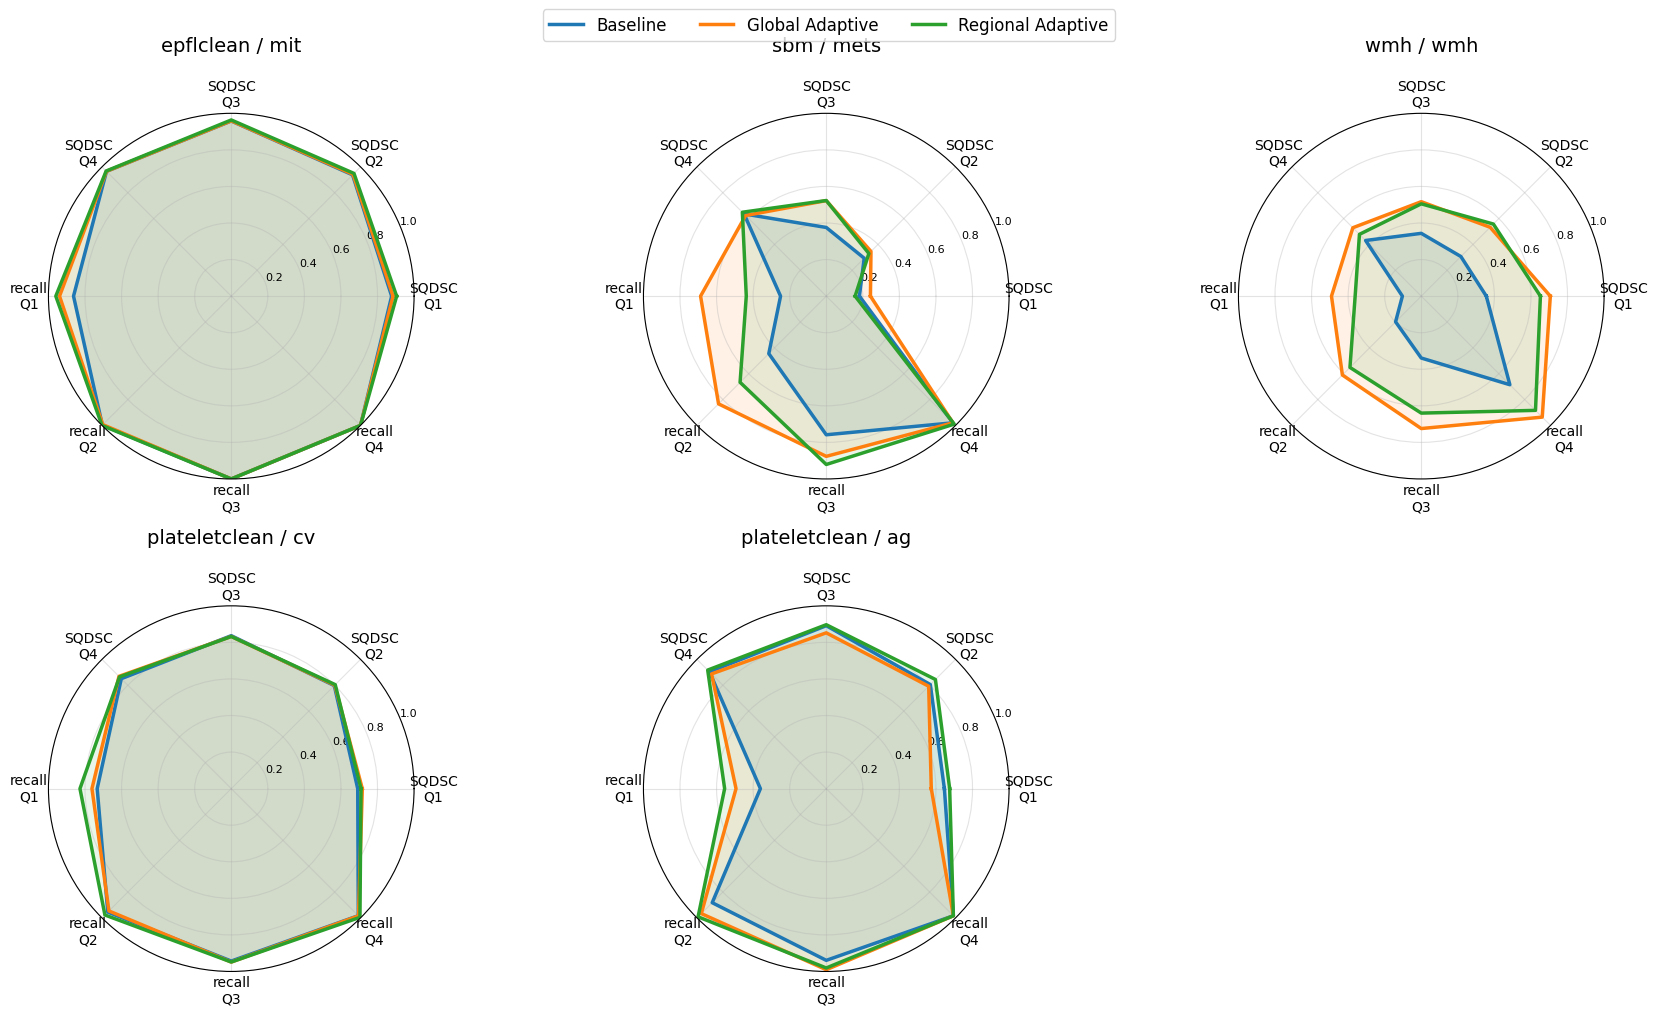

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# --- Configuration ---
SUPERSETS = ['epflclean', 'sbm', 'wmh', 'plateletclean', 'plateletclean']
TASKS = ["mit", 'mets', 'wmh', 'cv', 'ag']

metrics = ["SQDSC", "recall"]
quartiles = ["Q1", "Q2", "Q3", "Q4"]

# Octagon labels
labels = [
    f"{metric}\n{quartile}"
    for metric in metrics
    for quartile in quartiles
]

n_axes = len(labels)
angles = np.linspace(0, 2 * np.pi, n_axes, endpoint=False).tolist()
angles += angles[:1]  # close polygon


def get_values(df, config):
    """Extract ordered values across all quartiles and metrics."""
    values = []

    for metric in metrics:
        for quartile in quartiles:
            col = f"test/instance/{metric}_{quartile}"
            values.append(df.loc[config, col])

    return values


# --- Plotting ---
n_plots = len(supersets)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10),
    subplot_kw=dict(polar=True)
)

axes = axes.flatten()

for idx, (SUPERSET, TASK) in enumerate(zip(SUPERSETS, TASKS)):
    ax = axes[idx]

    baseline_config = ("110000", f"{SUPERSET}_{TASK}", "none")
    comparison_configs = [
        ("110000", f"{SUPERSET}_{TASK}", "v_mountains"),
        ("110110", f"{SUPERSET}_{TASK}", "v_mountains"),
    ]

    # Get values
    baseline = get_values(df, baseline_config)
    comp1 = get_values(df, comparison_configs[0])
    comp2 = get_values(df, comparison_configs[1])

    # Close polygons
    baseline += baseline[:1]
    comp1 += comp1[:1]
    comp2 += comp2[:1]

    # --- Plot lines ---
    ax.plot(
        angles,
        baseline,
        linewidth=2.5,
        label="Baseline",
    )
    ax.fill(
        angles,
        baseline,
        alpha=0.12,
    )

    ax.plot(
        angles,
        comp1,
        linewidth=2.5,
        label="Global Adaptive",
    )
    ax.fill(
        angles,
        comp1,
        alpha=0.10,
    )

    ax.plot(
        angles,
        comp2,
        linewidth=2.5,
        label="Regional Adaptive",
    )
    ax.fill(
        angles,
        comp2,
        alpha=0.10,
    )

    # --- Axis formatting ---
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10)

    ax.set_ylim(0, 1.0)  # adjust if metrics exceed 1
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(
        ["0.2", "0.4", "0.6", "0.8", "1.0"],
        fontsize=8
    )

    ax.grid(alpha=0.35)
    ax.set_title(
        f"{SUPERSET} / {TASK}",
        fontsize=14,
        pad=20
    )

# Remove unused subplot
if len(axes) > n_plots:
    fig.delaxes(axes[-1])

# Shared legend
handles, labels_legend = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels_legend,
    loc="upper center",
    ncol=3,
    fontsize=12,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout()
plt.show()

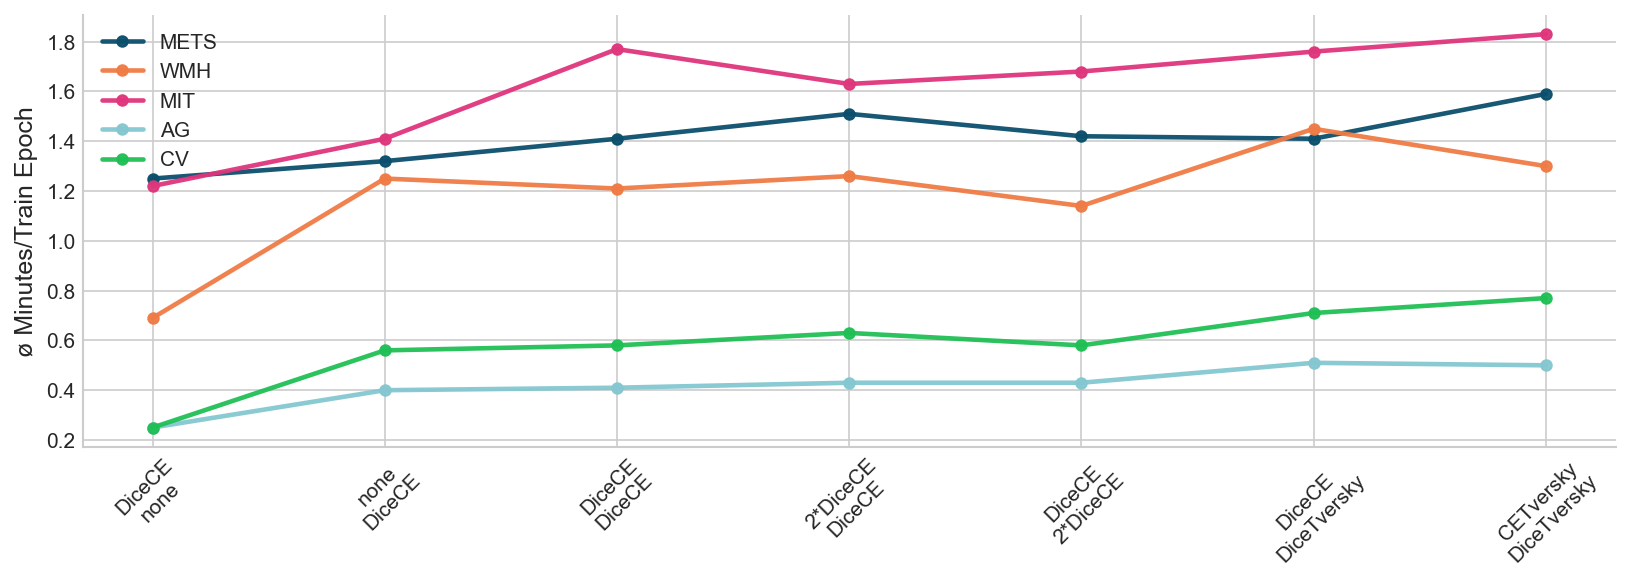

In [ ]:
data = {
    "dataset": [
        "METS",
        "WMH",
        "MIT",
        "AG",
        "CV"
    ],
    f"{readable_losses("110000")[0]}\n{readable_losses("110000")[1]}": [1.25, 0.69, 1.22, 0.25, 0.25],
    f"{readable_losses("000110")[0]}\n{readable_losses("000110")[1]}": [1.32, 1.25, 1.41, 0.40, 0.56],
    f"{readable_losses("110110")[0]}\n{readable_losses("110110")[1]}": [1.41, 1.21, 1.77, 0.41, 0.58],
    f"{readable_losses("220110")[0]}\n{readable_losses("220110")[1]}": [1.51, 1.26, 1.63, 0.43, 0.63],
    f"{readable_losses("110220")[0]}\n{readable_losses("110220")[1]}": [1.42, 1.14, 1.68, 0.43, 0.58],
    f"{readable_losses("110101")[0]}\n{readable_losses("110101")[1]}": [1.41, 1.45, 1.76, 0.51, 0.71],
    f"{readable_losses("011101")[0]}\n{readable_losses("011101")[1]}": [1.59, 1.30, 1.83, 0.50, 0.77],
}

dfrun = pd.DataFrame(data)

# Set dataset as index for easier plotting
dfrun = dfrun.set_index("dataset")

# ---- Customizable colors ----
colors = {
    "METS": "#0B4F6C",
    "WMH": "#EF7B45",
    "MIT": "#DF367C",
    "AG": "#84C7D0",
    "CV": "#20BF55"
}

plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False
})
fig, ax = plt.subplots(figsize=(11, 5))

for i, dataset in enumerate(dfrun.index):
    ax.plot(
        dfrun.columns,
        dfrun.loc[dataset],
        marker="o",
        linewidth=2.2,
        markersize=5,
        label=dataset,
        color=colors.get(dataset, None),
        alpha=0.95
    )

plt.ylabel("ø Minutes/Train Epoch")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()